# Study 7 — Results: Does the tuning compound?

Loads cached results from `outputs/study7_full/` (800 runs: 2 conditions x
200 images x 2 models, 2000 queries each).

Studies 1-6 settled on, in isolation:
  - `xi_step_scale=0.5`  (Study 3, validated at `lam_override=14`)
  - `bs_adaptive=True`   (Study 5, ~5-7% saved on binary search queries)
  - `tau=0`              (Study 6, + best_l2 running-min fix, validated at `lam_override=14`)
  - `cmu_scale=1.0`       (Study 3: already == baseline's default)
  - `lam_override=None`  (deliberately NOT changed -- left at baseline's
    default `4+3*ln(n)=28` for CIFAR-10, per explicit instruction; lam is
    deferred to a future study)

Both arms run through `evolba_tuned()` (so both get the `best_l2`
running-minimum fix uniformly -- not a confound):

```
BASELINE: xi_step_scale=1.0, tau=3, bs_steps=26, bs_adaptive=False, cmu_scale=1.0, lam_override=None
TUNED:    xi_step_scale=0.5, tau=0, bs_adaptive=True, bs_cap=26,    cmu_scale=1.0, lam_override=None
```

**Question.** Do the individually-validated improvements stack into a clear
net win, or do they interact/cancel once `lam` is held at baseline's value?


In [1]:
import pandas as pd, numpy as np, pickle
from IPython.display import Image, display

OUT = 'outputs/study7_full'
df = pd.read_parquet(f'{OUT}/results.parquet')
with open(f'{OUT}/trajectories.pkl', 'rb') as f:
    all_traj = pickle.load(f)

ok = df[df.success]
print(f'{len(df)} runs total, {len(ok)} successful ({df.success.mean()*100:.1f}%)')
ok.head()


800 runs total, 760 successful (95.0%)


,condition,model,image_idx,true_class,success,queries,init_l2,best_l2,final_l2,n_generations,backtracks_total,bs_calls,bs_queries_actual,l2_at_250,l2_at_500,l2_at_750,l2_at_1000,l2_at_1500,l2_at_2000,improvement_ratio
0,baseline,standard,0,3,True,2027,3.052553,1.795980,1.795980,29,9,39,1014,2.378383,2.293230,2.085185,2.084464,1.994872,1.934275,0.411647
1,baseline,standard,1,8,True,2027,4.176711,1.998545,2.002961,27,12,40,1040,2.676500,2.125148,2.107656,2.095685,2.042450,1.998545,0.521503
2,baseline,standard,2,8,True,2026,2.302839,1.652192,1.652819,8,7,16,416,1.901815,1.652192,1.652819,1.652819,1.652819,1.652819,0.282541
3,baseline,standard,3,0,True,2027,0.973804,0.540253,0.542401,30,9,40,1040,0.779333,0.650117,0.644751,0.618115,0.564443,0.540253,0.445214
4,baseline,standard,4,6,True,2026,12.981510,10.130859,10.164044,5,3,9,234,10.130859,10.164044,10.164044,10.164044,10.164044,10.164044,0.219593


## Summary table

In [2]:
COND_ORDER  = ['baseline', 'tuned']
MODEL_NAMES = ['standard', 'robust']

summary = ok.groupby(['condition','model']).agg(
    n               = ('best_l2', 'count'),
    median_init     = ('init_l2', 'median'),
    median_best     = ('best_l2', 'median'),
    median_final    = ('final_l2', 'median'),
    median_IR       = ('improvement_ratio', 'median'),
    median_gen      = ('n_generations', 'median'),
    median_queries  = ('queries', 'median'),
    median_bsq      = ('bs_queries_actual', 'median'),
).round(4)
summary = summary.reindex(
    pd.MultiIndex.from_product([COND_ORDER, MODEL_NAMES], names=['condition','model'])
)
summary


n  median_init  median_best  median_final  median_IR  \
condition model                                                              
baseline  standard  200       3.8041       2.4107        2.4116     0.3858   
          robust    180       7.5117       6.9856        7.0498     0.0599   
tuned     standard  200       3.8041       2.3925        2.3925     0.3801   
          robust    180       7.5117       7.1102        7.2388     0.0470   

                    median_gen  median_queries  median_bsq  
condition model                                             
baseline  standard        20.5          2026.0       884.0  
          robust          15.5          2026.0      1118.0  
tuned     standard        33.0          2023.0       878.5  
          robust          34.0          2025.0       910.0

## Headline result: the gains do NOT compound

| | xi_step_scale | tau | bs_steps | median_gen | standard IR | robust IR |
|---|---|---|---|---|---|---|
| **baseline** | 1.0 | 3 | 26 (fixed) | 16-20.5 | 0.386 | 0.060 |
| **tuned** | 0.5 | 0 | adaptive (cap 26) | 33-34 | 0.380 | 0.047 |

`tuned` delivers on its *mechanical* promise -- roughly **double** the
generations in both models (smaller steps + no backtracking + adaptive
binary search all save queries). But this does not translate into a better
attack:

- **standard**: a wash. IR 0.380 vs 0.386 (~-1.5% relative).
- **robust**: `tuned` is actually *worse*. IR 0.047 vs 0.060 (~-22% relative).


## A: Final L2 distributions

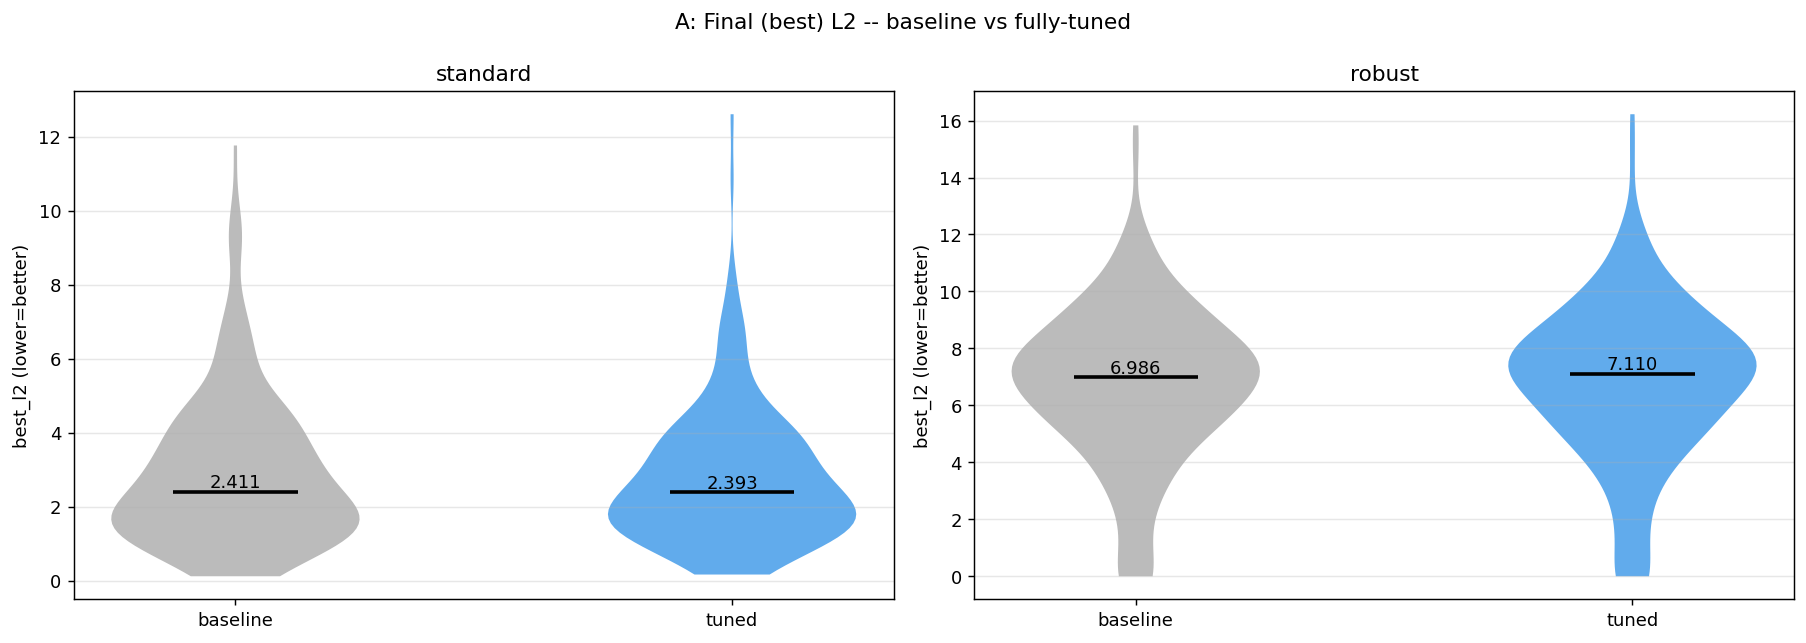

In [3]:
display(Image(f'{OUT}/A_final_l2.png'))

## B: Convergence curves

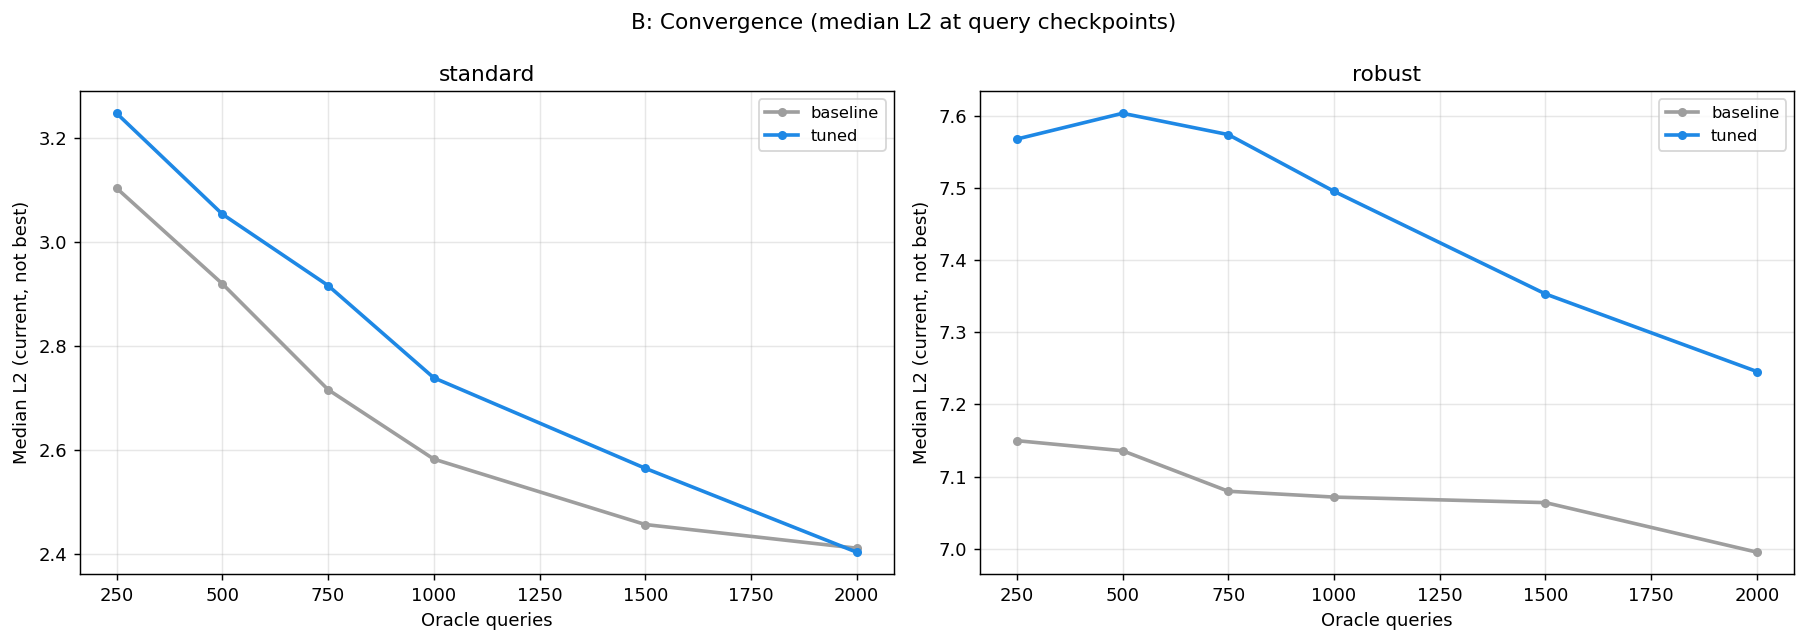

In [4]:
display(Image(f'{OUT}/B_convergence.png'))

For **standard**, `baseline` leads throughout Q=250-1500 and `tuned` only
catches up to parity by Q=2000.

For **robust**, `baseline` leads across the *entire* range, and `tuned`
never catches up (Q2000: baseline=7.00 vs tuned=7.26).


## C: Paired per-image comparison

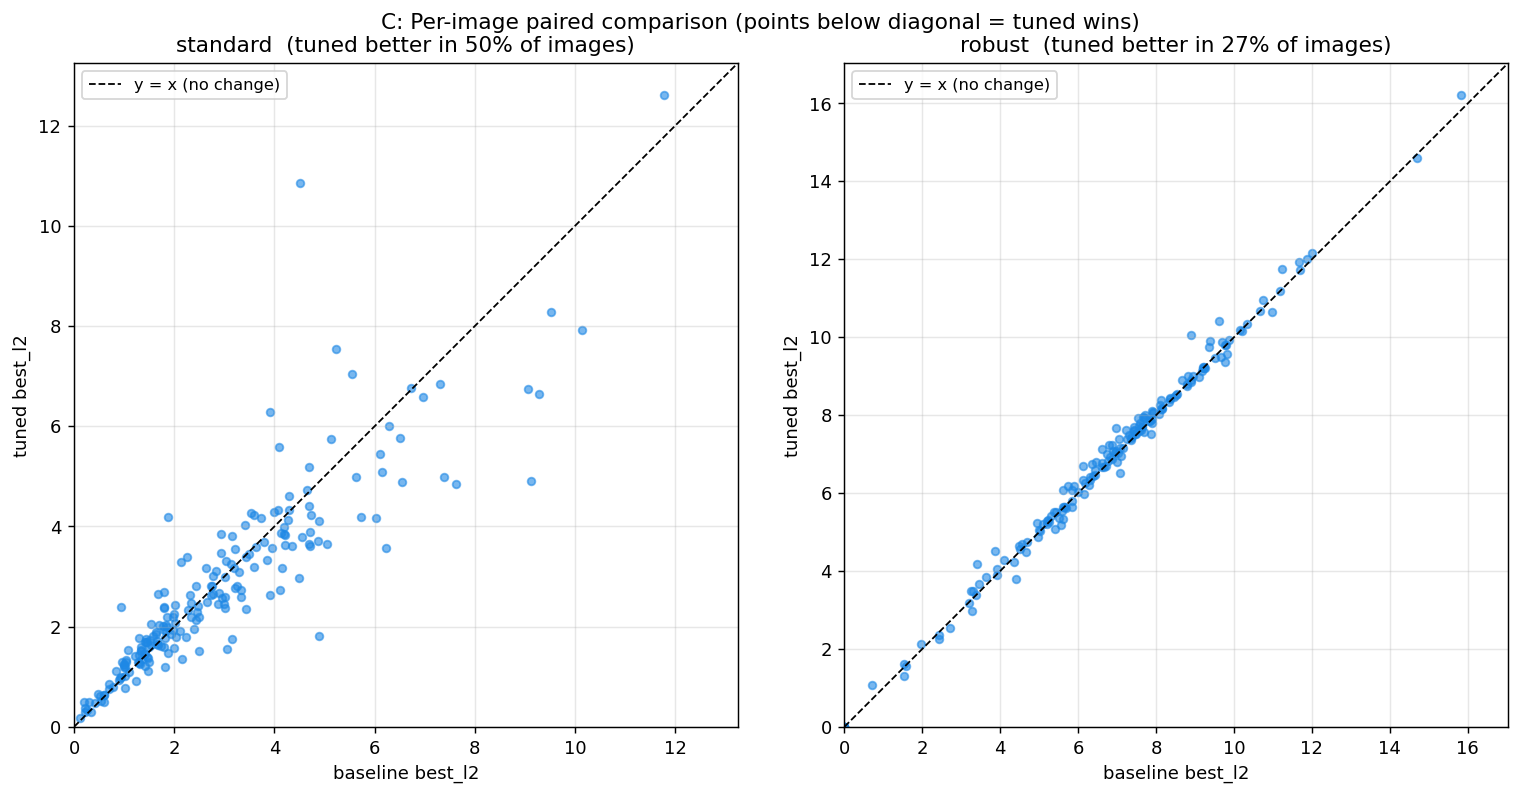

In [5]:
display(Image(f'{OUT}/C_paired.png'))

In [6]:
print('=== PAIRED COMPARISON (per image, tuned vs baseline) ===')
for mname in MODEL_NAMES:
    base = ok[(ok.condition=='baseline')&(ok.model==mname)].set_index('image_idx')['best_l2']
    tun  = ok[(ok.condition=='tuned')   &(ok.model==mname)].set_index('image_idx')['best_l2']
    common = base.index.intersection(tun.index)
    b, t_ = base.loc[common], tun.loc[common]
    win_rate = float((t_ < b).mean())
    rel_impr = float(np.median((b - t_) / b))
    print(f'{mname}: n={len(common)}  tuned-wins={win_rate*100:.1f}%  '
          f'median relative improvement={rel_impr*100:.1f}%')


=== PAIRED COMPARISON (per image, tuned vs baseline) ===
standard: n=200  tuned-wins=50.0%  median relative improvement=0.1%
robust: n=180  tuned-wins=26.7%  median relative improvement=-0.9%


**standard**: win rate 50.0%, median relative improvement +0.1% -- points
scatter evenly around the diagonal, no systematic edge either way.

**robust**: win rate only 26.7%, median relative improvement -0.9% -- points
are tightly clustered along the diagonal with a consistent slight bias
toward `tuned` being *worse*. Not a few outliers: a small, systematic
disadvantage across nearly the whole test set.


## D: Generations, query allocation, improvement ratio

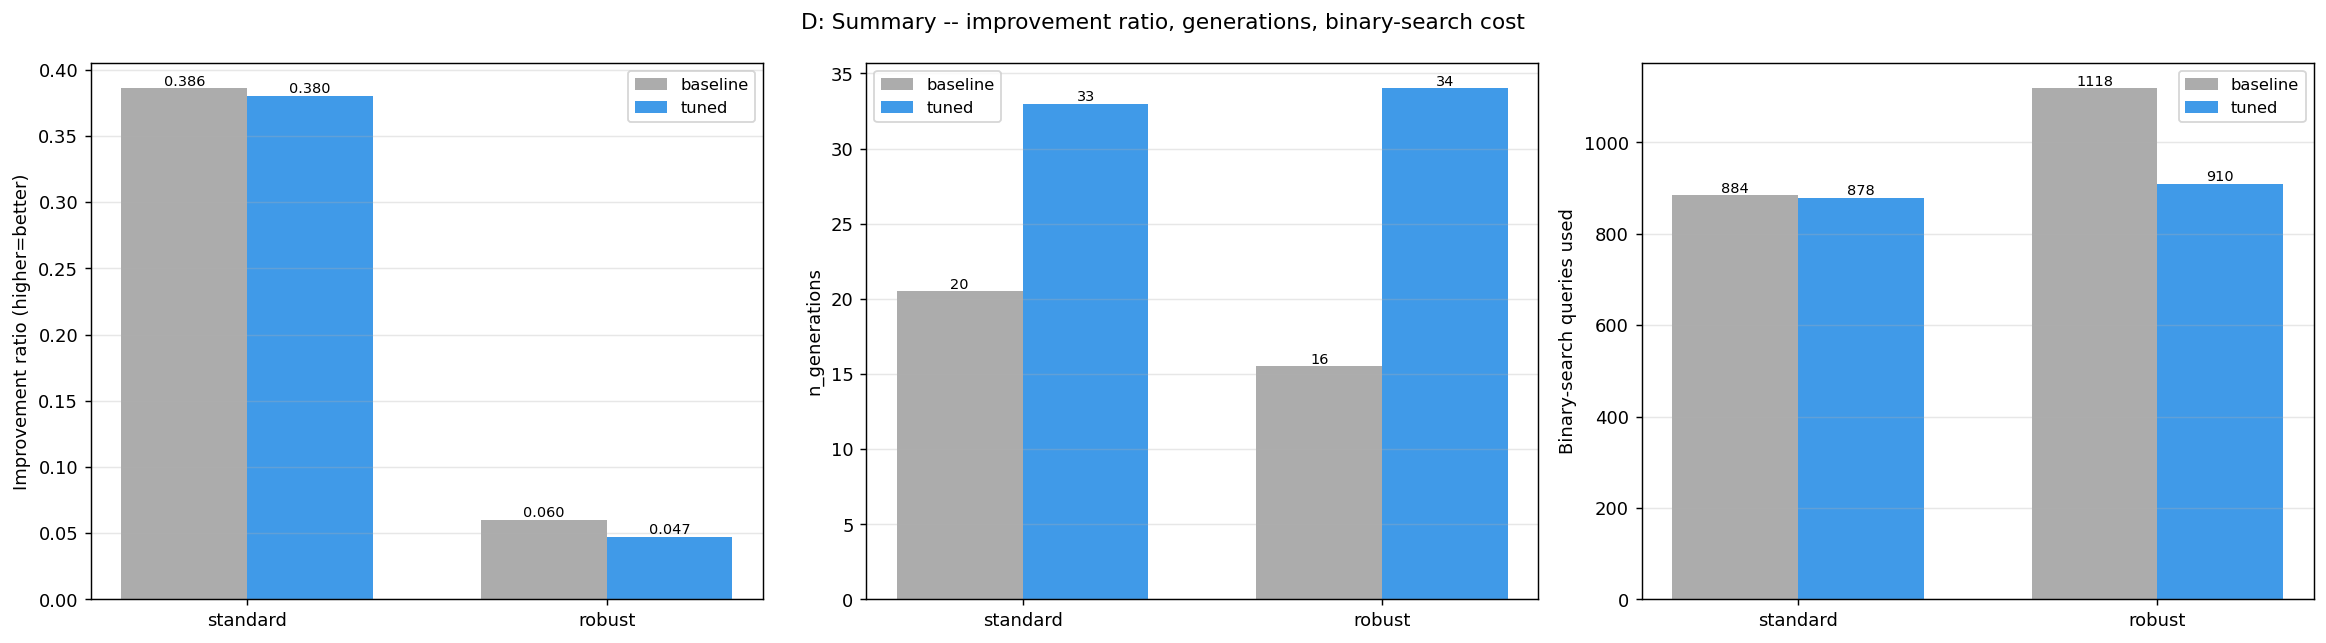

In [7]:
display(Image(f'{OUT}/D_summary.png'))

## Why doesn't doubling the generations help?

Compare to Study 6 (same `xi_step_scale=0.5, tau=0`, but at
`lam_override=14`): there, `tau=0` got **57-59** generations and
IR **0.441 / 0.071**. Here at `lam=28`, the *same* xi_scale=0.5/tau=0 combo
gets roughly half the generations (**33-34**, as expected -- `lam` sets
offspring-per-generation) -- but the IR *also* drops (0.441->0.380,
0.071->0.047), not just proportionally.

Meanwhile `baseline`'s bigger steps (`xi_step_scale=1.0`) extract enough
progress per generation that even with **half** the generations of `tuned`,
it keeps pace (standard) or wins outright (robust).

**Conclusion**: `xi_step_scale=0.5` was the right choice *for the lam=14
regime*, where generations are abundant (57-59) and many small steps
compound well. At `lam=28`, generations are scarcer (16-34), and bigger
steps per generation seem to matter more. `lam` is not an independent knob
-- it determines which step-size regime is optimal, so the Study 3/5/6
recommendations (found under `lam_override=14`) do not transfer cleanly to
`lam=28` as-is.

## Next step

`lam x xi_step_scale` is the natural joint sweep: does `xi_step_scale=0.5`
recover its Study-3/6 advantage once paired with a smaller `lam`, or does
`lam=28` + `xi_step_scale=1.0` (closer to baseline) remain the better
operating point regardless? Deferred to a future study.
